## Data Loading and Parsing

In [181]:
import pandas as pd

file_path = 'C:/Users/mohit/Desktop/CAD_Project/GSE20681_series_matrix.txt'

print(f"Reading file: {file_path} ...")
metadata_dict = {}
skip_lines = 0

with open(file_path, 'rt', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        skip_lines += 1
        if line.startswith('!Sample_'):
            parts = line.split('\t')
            key = parts[0].replace('!Sample_', '')
            values = [v.strip('"') for v in parts[1:]]
            if key == 'characteristics_ch1':
                if ':' in values[0]:
                    sub_key = values[0].split(':', 1)[0].strip()
                    clean_values = [v.split(':', 1)[1].strip() if ':' in v else v for v in values]
                    metadata_dict[sub_key] = clean_values
                else:
                    metadata_dict.setdefault(key, []).extend(values)
            else:
                metadata_dict[key] = values
        elif line.startswith('!series_matrix_table_begin'):
            break

df_metadata = pd.DataFrame(metadata_dict)
if 'geo_accession' in df_metadata.columns:
    df_metadata.set_index('geo_accession', inplace=True)

print("Extracting expression matrix...")
df_expression0 = pd.read_csv(file_path, sep='\t', skiprows=skip_lines, skipfooter=1, engine='python')
if 'ID_REF' in df_expression0.columns:
    df_expression0.set_index('ID_REF', inplace=True)

print("\nDone")

Reading file: C:/Users/mohit/Desktop/CAD_Project/GSE20681_series_matrix.txt ...
Extracting expression matrix...

Done


In [182]:
df_expression0

,GSM518885,GSM518886,GSM518887,GSM518888,GSM518889,GSM518890,GSM518891,GSM518892,GSM518893,GSM518894,...,GSM519073,GSM519074,GSM519075,GSM519076,GSM519077,GSM519078,GSM519079,GSM519080,GSM519081,GSM519082
ID_REF,,,,,,,,,,,,,,,,,,,,,
1,17.568052,18.128432,18.000360,17.946662,16.635963,17.044977,17.271164,17.905237,17.660148,17.282398,...,17.726255,17.580011,16.527358,17.914681,17.924773,17.495677,17.764805,17.639847,17.186921,16.935805
2,5.834896,5.845182,6.646780,5.870539,6.068259,5.891336,5.823895,6.103062,5.794360,5.772531,...,5.947902,6.133945,5.815684,6.312393,6.645411,5.865132,6.165802,6.106718,6.105625,6.332668
3,5.784200,5.819593,6.409190,5.870100,5.974745,5.887344,5.823406,6.194008,5.906630,5.773635,...,5.910306,5.888308,6.084636,6.350751,6.409190,5.862894,6.102790,6.017889,6.131528,5.942342
4,5.819712,5.828600,6.487272,5.869395,5.967861,5.884013,5.822878,6.053151,5.953187,5.774601,...,5.934432,5.883229,5.809368,6.080400,6.487272,5.860990,6.235280,6.092935,5.975808,5.891257
5,5.885071,5.780846,6.588942,5.868746,6.126353,5.880009,5.822275,6.212781,5.887118,5.775446,...,5.905341,5.878382,6.089065,6.168939,6.311523,5.859075,6.192452,6.172401,6.065957,6.270177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45216,5.770584,5.782947,5.961539,5.849523,5.964262,5.829789,5.778394,5.773404,5.780982,5.784183,...,5.822175,5.815626,5.847919,5.910767,6.196605,5.962680,5.840086,6.309823,6.312187,5.817221
45217,5.770914,5.780540,6.069091,5.849877,5.968225,5.827274,5.777826,6.159330,5.780678,5.822920,...,5.776327,5.816822,5.848438,6.128067,6.196284,5.840958,5.800065,6.198826,6.199917,6.199917
45218,5.771322,5.781091,6.109783,5.849677,6.181186,5.824250,5.777271,6.005361,5.850597,5.770017,...,5.779725,5.936801,5.848907,6.029191,6.133945,6.023621,5.798569,5.944130,6.220683,6.130219


In [183]:
df_metadata.head()

,title,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,disease state,pair,...,contact_email,contact_phone,contact_institute,contact_address,contact_city,contact_state,contact_zip/postal_code,contact_country,supplementary_file,data_row_count
geo_accession,,,,,,,,,,,,,,,,,,,,,
GSM518885,whole-blood_1_pair-1,Public on Mar 01 2011,Mar 08 2010,Apr 07 2014,RNA,1,"whole-blood,1,pair-1",Homo sapiens,Case (1),pair 1,...,jwingrove@cardiodx.com,650 475-2706,"CardioDx, Inc.",2500 Faber Place,CA,CA,94303,USA,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM518n...,45015
GSM518886,whole-blood_0_pair-1,Public on Mar 01 2011,Mar 08 2010,Apr 07 2014,RNA,1,"whole-blood,0,pair-1",Homo sapiens,Control (0),pair 1,...,jwingrove@cardiodx.com,650 475-2706,"CardioDx, Inc.",2500 Faber Place,CA,CA,94303,USA,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM518n...,45015
GSM518887,whole-blood_1_pair-10,Public on Mar 01 2011,Mar 08 2010,Apr 07 2014,RNA,1,"whole-blood,1,pair-10",Homo sapiens,Case (1),pair 10,...,jwingrove@cardiodx.com,650 475-2706,"CardioDx, Inc.",2500 Faber Place,CA,CA,94303,USA,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM518n...,45015
GSM518888,whole-blood_0_pair-10,Public on Mar 01 2011,Mar 08 2010,Apr 07 2014,RNA,1,"whole-blood,0,pair-10",Homo sapiens,Control (0),pair 10,...,jwingrove@cardiodx.com,650 475-2706,"CardioDx, Inc.",2500 Faber Place,CA,CA,94303,USA,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM518n...,45015
GSM518889,whole-blood_1_pair-100,Public on Mar 01 2011,Mar 08 2010,Apr 07 2014,RNA,1,"whole-blood,1,pair-100",Homo sapiens,Case (1),pair 100,...,jwingrove@cardiodx.com,650 475-2706,"CardioDx, Inc.",2500 Faber Place,CA,CA,94303,USA,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM518n...,45015


In [184]:
df_metadata['disease state'].head(2)

geo_accession
GSM518885       Case (1)
GSM518886    Control (0)
Name: disease state, dtype: object

## Data Preprocessing

In [185]:
import numpy as np

df_expression = df_expression0.dropna(axis=0, how='any')
print(f"Dropped {df_expression0.shape[0] - df_expression.shape[0]} probes due to missing values.")
df_expression

Dropped 0 probes due to missing values.


,GSM518885,GSM518886,GSM518887,GSM518888,GSM518889,GSM518890,GSM518891,GSM518892,GSM518893,GSM518894,...,GSM519073,GSM519074,GSM519075,GSM519076,GSM519077,GSM519078,GSM519079,GSM519080,GSM519081,GSM519082
ID_REF,,,,,,,,,,,,,,,,,,,,,
1,17.568052,18.128432,18.000360,17.946662,16.635963,17.044977,17.271164,17.905237,17.660148,17.282398,...,17.726255,17.580011,16.527358,17.914681,17.924773,17.495677,17.764805,17.639847,17.186921,16.935805
2,5.834896,5.845182,6.646780,5.870539,6.068259,5.891336,5.823895,6.103062,5.794360,5.772531,...,5.947902,6.133945,5.815684,6.312393,6.645411,5.865132,6.165802,6.106718,6.105625,6.332668
3,5.784200,5.819593,6.409190,5.870100,5.974745,5.887344,5.823406,6.194008,5.906630,5.773635,...,5.910306,5.888308,6.084636,6.350751,6.409190,5.862894,6.102790,6.017889,6.131528,5.942342
4,5.819712,5.828600,6.487272,5.869395,5.967861,5.884013,5.822878,6.053151,5.953187,5.774601,...,5.934432,5.883229,5.809368,6.080400,6.487272,5.860990,6.235280,6.092935,5.975808,5.891257
5,5.885071,5.780846,6.588942,5.868746,6.126353,5.880009,5.822275,6.212781,5.887118,5.775446,...,5.905341,5.878382,6.089065,6.168939,6.311523,5.859075,6.192452,6.172401,6.065957,6.270177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45216,5.770584,5.782947,5.961539,5.849523,5.964262,5.829789,5.778394,5.773404,5.780982,5.784183,...,5.822175,5.815626,5.847919,5.910767,6.196605,5.962680,5.840086,6.309823,6.312187,5.817221
45217,5.770914,5.780540,6.069091,5.849877,5.968225,5.827274,5.777826,6.159330,5.780678,5.822920,...,5.776327,5.816822,5.848438,6.128067,6.196284,5.840958,5.800065,6.198826,6.199917,6.199917
45218,5.771322,5.781091,6.109783,5.849677,6.181186,5.824250,5.777271,6.005361,5.850597,5.770017,...,5.779725,5.936801,5.848907,6.029191,6.133945,6.023621,5.798569,5.944130,6.220683,6.130219


In [186]:
max_val = df_expression.max().max()
round(max_val,2)

np.float64(19.35)

In [187]:
if max_val < 50:
    print("Data scale suggests it is ALREADY log2-transformed. Preserving biological variance.")
    df_expression = df_expression
else:
    print("Applying Log2 transformation (log2(x + 1))...")
    df_expression = np.log2(df_expression + 1)
    
print(f"Final preprocessed matrix shape: {df_expression.shape[0]} genes, {df_expression.shape[1]} patients.")


Data scale suggests it is ALREADY log2-transformed. Preserving biological variance.
Final preprocessed matrix shape: 45015 genes, 198 patients.


In [188]:
df_expression.head()

,GSM518885,GSM518886,GSM518887,GSM518888,GSM518889,GSM518890,GSM518891,GSM518892,GSM518893,GSM518894,...,GSM519073,GSM519074,GSM519075,GSM519076,GSM519077,GSM519078,GSM519079,GSM519080,GSM519081,GSM519082
ID_REF,,,,,,,,,,,,,,,,,,,,,
1,17.568052,18.128432,18.000360,17.946662,16.635963,17.044977,17.271164,17.905237,17.660148,17.282398,...,17.726255,17.580011,16.527358,17.914681,17.924773,17.495677,17.764805,17.639847,17.186921,16.935805
2,5.834896,5.845182,6.646780,5.870539,6.068259,5.891336,5.823895,6.103062,5.794360,5.772531,...,5.947902,6.133945,5.815684,6.312393,6.645411,5.865132,6.165802,6.106718,6.105625,6.332668
3,5.784200,5.819593,6.409190,5.870100,5.974745,5.887344,5.823406,6.194008,5.906630,5.773635,...,5.910306,5.888308,6.084636,6.350751,6.409190,5.862894,6.102790,6.017889,6.131528,5.942342
4,5.819712,5.828600,6.487272,5.869395,5.967861,5.884013,5.822878,6.053151,5.953187,5.774601,...,5.934432,5.883229,5.809368,6.080400,6.487272,5.860990,6.235280,6.092935,5.975808,5.891257
5,5.885071,5.780846,6.588942,5.868746,6.126353,5.880009,5.822275,6.212781,5.887118,5.775446,...,5.905341,5.878382,6.089065,6.168939,6.311523,5.859075,6.192452,6.172401,6.065957,6.270177


In [189]:
df_expression.dtypes.value_counts()

float64    198
Name: count, dtype: int64

## Differential Gene Expression (DGE) Analysis

In [190]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

# We use df_metadata and final_df from the previous steps
df_metadata['is_case'] = df_metadata['disease state'].str.contains('Case').astype(int)
df_metadata.head(3)

,title,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,disease state,pair,...,contact_phone,contact_institute,contact_address,contact_city,contact_state,contact_zip/postal_code,contact_country,supplementary_file,data_row_count,is_case
geo_accession,,,,,,,,,,,,,,,,,,,,,
GSM518885,whole-blood_1_pair-1,Public on Mar 01 2011,Mar 08 2010,Apr 07 2014,RNA,1,"whole-blood,1,pair-1",Homo sapiens,Case (1),pair 1,...,650 475-2706,"CardioDx, Inc.",2500 Faber Place,CA,CA,94303,USA,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM518n...,45015,1
GSM518886,whole-blood_0_pair-1,Public on Mar 01 2011,Mar 08 2010,Apr 07 2014,RNA,1,"whole-blood,0,pair-1",Homo sapiens,Control (0),pair 1,...,650 475-2706,"CardioDx, Inc.",2500 Faber Place,CA,CA,94303,USA,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM518n...,45015,0
GSM518887,whole-blood_1_pair-10,Public on Mar 01 2011,Mar 08 2010,Apr 07 2014,RNA,1,"whole-blood,1,pair-10",Homo sapiens,Case (1),pair 10,...,650 475-2706,"CardioDx, Inc.",2500 Faber Place,CA,CA,94303,USA,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM518n...,45015,1


In [191]:
#Getting IDs from Metadata
case_ids = df_metadata[df_metadata['is_case'] == 1].index.intersection(df_expression.columns) 
# uses .intersection(df_expression.columns) to ensure it only analyzes patients that exist in both metadata file and expression matrix.

In [192]:
control_ids = df_metadata[df_metadata['is_case'] == 0].index.intersection(df_expression.columns)
control_ids

Index(['GSM518886', 'GSM518888', 'GSM518890', 'GSM518892', 'GSM518894',
       'GSM518896', 'GSM518898', 'GSM518900', 'GSM518902', 'GSM518904',
       'GSM518906', 'GSM518908', 'GSM518910', 'GSM518912', 'GSM518914',
       'GSM518916', 'GSM518918', 'GSM518920', 'GSM518922', 'GSM518924',
       'GSM518926', 'GSM518928', 'GSM518930', 'GSM518932', 'GSM518934',
       'GSM518936', 'GSM518938', 'GSM518940', 'GSM518942', 'GSM518944',
       'GSM518946', 'GSM518948', 'GSM518950', 'GSM518952', 'GSM518954',
       'GSM518956', 'GSM518958', 'GSM518960', 'GSM518962', 'GSM518964',
       'GSM518966', 'GSM518968', 'GSM518970', 'GSM518972', 'GSM518974',
       'GSM518976', 'GSM518978', 'GSM518980', 'GSM518982', 'GSM518984',
       'GSM518986', 'GSM518988', 'GSM518990', 'GSM518992', 'GSM518994',
       'GSM518996', 'GSM518998', 'GSM519000', 'GSM519002', 'GSM519004',
       'GSM519006', 'GSM519008', 'GSM519010', 'GSM519012', 'GSM519014',
       'GSM519016', 'GSM519018', 'GSM519020', 'GSM519022', 'GSM5

In [193]:
gene_variances = df_expression.var(axis=1)
gene_variances

ID_REF
1        0.220291
2        0.037447
3        0.023469
4        0.024374
5        0.027602
           ...   
45216    0.012027
45217    0.011522
45218    0.012655
45219    0.199284
45220    0.189547
Length: 45015, dtype: float64

In [194]:
median_variance = gene_variances.median()
print(median_variance)

0.04870444794431341


In [195]:
variable_genes = gene_variances[gene_variances >= median_variance].index
variable_genes.value_counts().sum()

np.int64(22508)

In [196]:
df_filt_exp = df_expression.loc[variable_genes]
df_filt_exp.head()


,GSM518885,GSM518886,GSM518887,GSM518888,GSM518889,GSM518890,GSM518891,GSM518892,GSM518893,GSM518894,...,GSM519073,GSM519074,GSM519075,GSM519076,GSM519077,GSM519078,GSM519079,GSM519080,GSM519081,GSM519082
ID_REF,,,,,,,,,,,,,,,,,,,,,
1,17.568052,18.128432,18.000360,17.946662,16.635963,17.044977,17.271164,17.905237,17.660148,17.282398,...,17.726255,17.580011,16.527358,17.914681,17.924773,17.495677,17.764805,17.639847,17.186921,16.935805
12,11.959462,10.179093,9.409054,9.406748,10.961677,11.481034,11.381839,10.474357,10.720312,10.097759,...,11.365464,10.844680,12.064798,11.439404,11.749052,11.412093,11.840440,11.162866,10.817178,10.966946
13,6.724463,6.253198,6.683456,6.108898,6.337433,6.070121,6.676301,6.785306,6.752405,6.492718,...,6.870282,6.405818,7.362950,6.869764,6.673497,6.509899,6.927634,6.070121,6.467751,6.538747
14,8.988431,8.021553,8.171563,8.022946,9.472198,9.220005,9.086230,8.679196,8.944825,8.892963,...,9.132285,9.104096,9.922581,9.287454,9.200059,9.228191,9.401997,8.696071,9.758423,9.534309
16,10.667113,10.265153,10.043030,10.043030,11.163540,11.286250,10.908731,10.557458,10.781992,10.442533,...,10.200372,10.311883,10.961677,10.402753,10.286550,10.348944,10.539480,10.154639,10.943799,11.037519


In [197]:
df_filt_exp.shape

(22508, 198)

In [198]:
cases_data = df_filt_exp[case_ids]
controls_data = df_filt_exp[control_ids]

In [199]:
cases_data.head(2)

,GSM518885,GSM518887,GSM518889,GSM518891,GSM518893,GSM518895,GSM518897,GSM518899,GSM518901,GSM518903,...,GSM519063,GSM519065,GSM519067,GSM519069,GSM519071,GSM519073,GSM519075,GSM519077,GSM519079,GSM519081
ID_REF,,,,,,,,,,,,,,,,,,,,,
1,17.568052,18.000360,16.635963,17.271164,17.660148,17.375470,17.505922,17.407126,17.474353,17.516466,...,17.528394,17.815529,17.736168,17.385722,16.736421,17.726255,16.527358,17.924773,17.764805,17.186921
12,11.959462,9.409054,10.961677,11.381839,10.720312,10.503494,10.600672,11.203516,11.031924,10.592752,...,11.088832,11.505813,10.943134,11.768140,11.510076,11.365464,12.064798,11.749052,11.840440,10.817178


In [200]:
cases_data.loc[12]

GSM518885    11.959462
GSM518887     9.409054
GSM518889    10.961677
GSM518891    11.381839
GSM518893    10.720312
               ...    
GSM519073    11.365464
GSM519075    12.064798
GSM519077    11.749052
GSM519079    11.840440
GSM519081    10.817178
Name: 12, Length: 99, dtype: float64

Running t-tests and calculating fold changes

In [201]:
results = []

for gene in df_filt_exp.index:
    case_vals = cases_data.loc[gene].dropna()
    control_vals = controls_data.loc[gene].dropna()
    if len(case_vals) < 3 or len(control_vals) < 3: 
        continue
        
    t_stat, p_val = stats.ttest_ind(case_vals, control_vals, equal_var=False)
    log2fc = case_vals.mean() - control_vals.mean()
    
    results.append({
        'Gene_Probe': gene,
        'Log2FC': log2fc,
        'Abs_Log2FC': abs(log2fc),
        'p_value': p_val
    })

In [202]:
dge_df = pd.DataFrame(results).dropna()
dge_df

,Gene_Probe,Log2FC,Abs_Log2FC,p_value
0,1,-0.110708,0.110708,0.097186
1,12,0.146609,0.146609,0.082381
2,13,0.007730,0.007730,0.885154
3,14,0.061206,0.061206,0.291331
4,16,0.057501,0.057501,0.201240
...,...,...,...,...
22503,45206,-0.001424,0.001424,0.971353
22504,45208,0.006373,0.006373,0.867772
22505,45209,0.010262,0.010262,0.786967
22506,45219,-0.050272,0.050272,0.429632


In [203]:
dge_df['FDR'] = multipletests(dge_df['p_value'], method='fdr_bh')[1]
dge_df = dge_df.sort_values(by='FDR', ascending = True)
dge_df

,Gene_Probe,Log2FC,Abs_Log2FC,p_value,FDR
22500,45201,-0.053870,0.053870,0.312392,0.999498
22465,45118,0.104008,0.104008,0.041922,0.999498
22466,45122,0.004333,0.004333,0.924713,0.999498
22467,45123,0.067715,0.067715,0.060542,0.999498
22468,45125,-0.030285,0.030285,0.404517,0.999498
...,...,...,...,...,...
10981,21893,0.000004,0.000004,0.999937,0.999944
18718,37208,0.000006,0.000006,0.999944,0.999944
16657,33122,0.000019,0.000019,0.999803,0.999944
11988,23852,0.000004,0.000004,0.999918,0.999944


## Machine Learning & Hyperparameter Tuning

In [204]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix

# Feature Selection (Updated threshold to 0.05)
top_genes = dge_df[(dge_df['p_value'] < 0.05) & (dge_df['Abs_Log2FC'] >= 0.25)]['Gene_Probe'].astype(str).tolist()
print(f"Selected {len(top_genes)} highly significant genes as features.\n")

Selected 32 highly significant genes as features.



In [205]:
print(top_genes)

['833', '1570', '1678', '2251', '3812', '9543', '14430', '14852', '16133', '18058', '19551', '21314', '21363', '24082', '25209', '25413', '26523', '28592', '28675', '29202', '29939', '32877', '32962', '34373', '34757', '35952', '37657', '40398', '40622', '41751', '43966', '44612']


In [206]:
df_metadata.index

Index(['GSM518885', 'GSM518886', 'GSM518887', 'GSM518888', 'GSM518889',
       'GSM518890', 'GSM518891', 'GSM518892', 'GSM518893', 'GSM518894',
       ...
       'GSM519073', 'GSM519074', 'GSM519075', 'GSM519076', 'GSM519077',
       'GSM519078', 'GSM519079', 'GSM519080', 'GSM519081', 'GSM519082'],
      dtype='object', name='geo_accession', length=198)

In [207]:
df_expression.index = df_expression.index.astype(str)
X = df_expression.loc[top_genes].T

y = df_metadata.loc[X.index,'is_case']

In [208]:
X

ID_REF,833,1570,1678,2251,3812,9543,14430,14852,16133,18058,...,32962,34373,34757,35952,37657,40398,40622,41751,43966,44612
GSM518885,5.774854,15.561015,15.539678,12.099264,11.595735,7.878449,15.604021,15.619751,7.261976,13.759500,...,12.995397,10.643878,9.063346,10.584895,11.484378,15.659053,9.394386,11.887825,12.730009,15.670415
GSM518886,5.774854,13.864315,13.852180,11.154829,8.618016,8.070609,13.987396,14.020404,6.766259,11.829374,...,11.950709,8.948057,8.493671,9.312001,9.205275,13.977549,9.724008,10.921089,12.995397,14.081311
GSM518887,5.899102,13.302790,13.283228,11.202092,8.930408,9.941519,13.294828,13.384449,7.164460,11.320833,...,11.648348,9.824767,8.050919,9.734759,10.736703,13.230535,10.649727,11.615165,13.327100,13.329071
GSM518888,5.857320,12.524207,12.612475,10.671387,8.986408,8.368572,12.626087,12.624930,6.807790,11.178936,...,11.978333,10.355695,8.442449,9.157130,10.024991,12.563967,7.557767,10.373359,13.503201,12.663841
GSM518889,9.952683,14.530164,14.496628,11.757185,10.174285,8.027842,14.499919,14.503182,9.420928,12.127216,...,13.437542,9.288730,9.312001,8.899280,11.187682,14.432803,9.205547,11.955016,13.704738,14.429563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM519078,5.944310,13.987396,13.979845,11.114870,10.400239,8.114415,13.994707,14.052861,7.153936,11.702597,...,13.123216,10.344825,8.622102,9.449831,9.497022,13.922351,10.161579,11.137129,13.290605,13.982442
GSM519079,5.854424,14.980869,15.036230,11.350014,9.351899,7.383744,15.040688,15.075667,7.377222,10.697395,...,13.510081,9.076999,8.402159,9.148480,10.871869,14.977231,9.154638,12.018773,14.198889,15.008582
GSM519080,5.888793,14.317755,14.357643,10.319957,10.071319,7.828489,14.388385,14.407137,7.380769,11.718006,...,12.804391,8.608217,8.933289,9.770112,9.164323,14.335749,10.458255,10.869104,13.905362,14.351041
GSM519081,5.879321,13.407347,13.391415,10.507971,8.585182,10.787555,13.413693,13.377987,7.553053,11.508304,...,13.338799,10.784475,8.014061,8.932993,9.889168,13.418139,8.431025,11.659292,12.493610,13.126926


In [209]:
y

GSM518885    1
GSM518886    0
GSM518887    1
GSM518888    0
GSM518889    1
            ..
GSM519078    0
GSM519079    1
GSM519080    0
GSM519081    1
GSM519082    0
Name: is_case, Length: 198, dtype: int64

In [210]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [211]:
# Define the Grid for Hyperparameter Tuning

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [212]:
grid_search.best_params_


{'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 500}

In [213]:
# Evaluate the Best Model
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1] # Get probabilities for the positive class (Case)

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba) # Calculate the Area Under the Curve

print("\n--- Tuned Model Evaluation ---")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"ROC-AUC Score:    {roc_auc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['Control (0)', 'Case (1)']))
print(confusion_matrix(y_test, y_pred))


--- Tuned Model Evaluation ---
Accuracy: 66.67%
ROC-AUC Score:    0.6456

Classification Report:
               precision    recall  f1-score   support

 Control (0)       0.66      0.70      0.68        30
    Case (1)       0.68      0.63      0.66        30

    accuracy                           0.67        60
   macro avg       0.67      0.67      0.67        60
weighted avg       0.67      0.67      0.67        60

[[21  9]
 [11 19]]


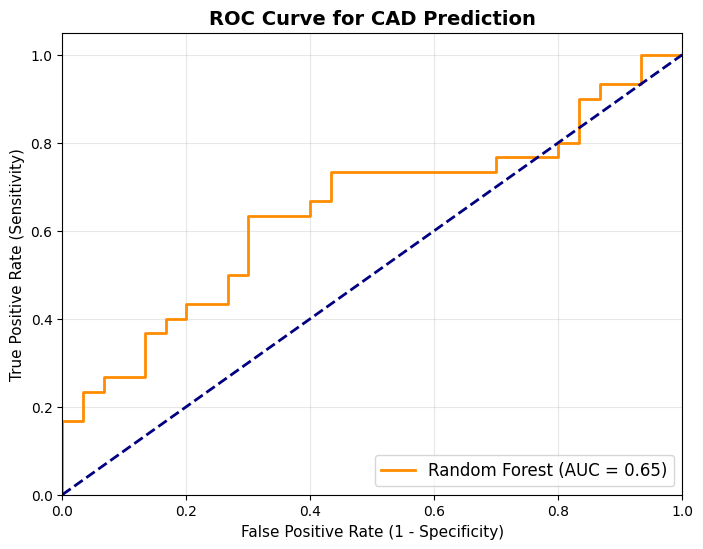

In [214]:
# Plotting the ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The random guessing baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('ROC Curve for CAD Prediction', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()



In [215]:
# Extract Top 15 Features
feature_importance_df = pd.DataFrame({
    'Gene_Probe': X.columns,
    'RF_Importance': best_rf.feature_importances_
}).sort_values('RF_Importance', ascending=False)

top_15_features = feature_importance_df.head(15)
print("\n--- Phase 4 Complete ---")

top_15_features


--- Phase 4 Complete ---


,Gene_Probe,RF_Importance
13,24082,0.108780
9,18058,0.056920
5,9543,0.053965
25,35952,0.047813
16,26523,0.042314
10,19551,0.038532
30,43966,0.037499
24,34757,0.033760
23,34373,0.032576
22,32962,0.032561


## Evaluation and Biological Mapping

In [216]:
# Using top_15_features from Phase 4 and dge_df from Phase 3
rf_features_copy = top_15_features.copy()
dge_copy = dge_df.copy()

rf_features_copy['Gene_Probe'] = rf_features_copy['Gene_Probe'].astype(str)
dge_copy['Gene_Probe'] = dge_copy['Gene_Probe'].astype(str)

# Merge the Random Forest importance scores with the DGE stats (Log2FC, p_value, FDR)
merged_stats = pd.merge(rf_features_copy, dge_copy, on='Gene_Probe', how='left')

In [217]:
merged_stats.head(2)

,Gene_Probe,RF_Importance,Log2FC,Abs_Log2FC,p_value,FDR
0,24082,0.10878,-0.609256,0.609256,0.004781,0.999498
1,18058,0.05692,0.416570,0.416570,0.000205,0.999498


In [218]:
annot_file = 'C:/Users/mohit/Desktop/CAD_Project/GPL4133.annot' 

skip_lines = 0
with open(annot_file, 'rt', encoding='utf-8') as f:
    for line in f:
        skip_lines += 1
        if line.startswith('!platform_table_begin'): 
            break
            
annot_df = pd.read_csv(annot_file, sep='\t', skiprows=skip_lines, engine='python')

In [219]:
annot_df

,ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,...,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID,Platform_SEQUENCE
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,GE_BrightCorner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,DarkCorner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,DarkCorner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,DarkCorner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,DarkCorner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45216,45217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,DarkCorner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45217,45218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,DarkCorner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45218,45219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,GE_BrightCorner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45219,45220,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,GE_BrightCorner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [220]:
# Map the biological names to the probe IDs
df_map = pd.merge(merged_stats, annot_df, left_on='Gene_Probe', right_on='ID', how='left')
df_map.head()

,Gene_Probe,RF_Importance,Log2FC,Abs_Log2FC,p_value,FDR,ID,Gene title,Gene symbol,Gene ID,...,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID,Platform_SEQUENCE
0,24082,0.108780,-0.609256,0.609256,0.004781,0.999498,24082,hemoglobin subunit zeta,HBZ,3050,...,A_23_P3651,16p13.3,"Chromosome 16, NC_000016.10 (142422..154511)",heme binding///iron ion binding///oxygen bindi...,erythrocyte maturation///negative regulation o...,extracellular exosome///hemoglobin complex,GO:0020037///GO:0005506///GO:0019825///GO:0005...,GO:0043249///GO:0000122///GO:0015671,GO:0070062///GO:0005833,AAGTTCCTATCGGTCGTATCCTCTGTCCTGACCGAGAAGTACCGCT...
1,18058,0.056920,0.416570,0.416570,0.000205,0.999498,18058,interleukin 18 receptor accessory protein,IL18RAP,8807,...,A_23_P28334,2q12,"Chromosome 2, NC_000002.12 (102418551..102452568)",receptor activity,cell surface receptor signaling pathway///cell...,integral component of membrane///plasma membrane,GO:0004872,GO:0007166///GO:0071345///GO:0070301///GO:0006...,GO:0016021///GO:0005886,CTAAGATTTCCCAGTGGTCCGAGCAGAATCAGAAAATACAGCTACT...
2,9543,0.053965,0.322219,0.322219,0.030414,0.999498,9543,C-C motif chemokine ligand 3,CCL3,6348,...,A_23_P373017,17q12,"Chromosome 17, NC_000017.11 (36088256..3609016...",CCR1 chemokine receptor binding///CCR5 chemoki...,G-protein coupled receptor signaling pathway//...,cytoplasm///cytosol///extracellular region///e...,GO:0031726///GO:0031730///GO:0004698///GO:0042...,GO:0007186///GO:0000165///GO:0000165///GO:0010...,GO:0005737///GO:0005829///GO:0005576///GO:0005...,TGGGAAACATGCGTGTGACCTCCACAGCTACCTCTTCTATGGACTG...
3,35952,0.047813,0.271136,0.271136,0.007258,0.999498,35952,NaN,NaN,NaN,...,A_24_P636974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GTGGGAGGGGCCGGTGTGAGGCAAGGCTCACGCTGACCTCTCTCGG...
4,26523,0.042314,0.253898,0.253898,0.018376,0.999498,26523,golgin A6 family-like 1,GOLGA6L1,283767,...,A_24_P50972,15q11.2,"Chromosome 15, NC_000015.10 (23127066..2313683...",NaN,NaN,NaN,NaN,NaN,NaN,GCAGCAAGGCCTGGAGAAGAGTAAGCCGCCATGTGACTGTTTAGAA...


In [221]:
df_final_map = df_map[['Gene_Probe', 'Gene symbol', 'Gene title', 'RF_Importance', 'Log2FC', 'p_value', 'FDR']]
df_final_map

,Gene_Probe,Gene symbol,Gene title,RF_Importance,Log2FC,p_value,FDR
0,24082,HBZ,hemoglobin subunit zeta,0.108780,-0.609256,0.004781,0.999498
1,18058,IL18RAP,interleukin 18 receptor accessory protein,0.056920,0.416570,0.000205,0.999498
2,9543,CCL3,C-C motif chemokine ligand 3,0.053965,0.322219,0.030414,0.999498
3,35952,NaN,NaN,0.047813,0.271136,0.007258,0.999498
4,26523,GOLGA6L1,golgin A6 family-like 1,0.042314,0.253898,0.018376,0.999498
5,19551,TPST1,tyrosylprotein sulfotransferase 1,0.038532,0.330755,0.003615,0.999498
6,43966,HLA-DPB1,"major histocompatibility complex, class II, DP...",0.037499,-0.268183,0.001524,0.999498
7,34757,TNFAIP6,TNF alpha induced protein 6,0.033760,0.261665,0.006004,0.999498
8,34373,RGPD2,RANBP2-like and GRIP domain containing 2,0.032576,0.278550,0.027852,0.999498
9,32962,FCGR2A,Fc fragment of IgG receptor IIa,0.032561,0.254898,0.004320,0.999498


## Data Visualization

In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

df_final_map_copy = df_final_map.copy()

df_final_map_copy['Display_Name'] = df_final_map_copy['Gene symbol'].fillna('Probe: ' + df_final_map_copy['Gene_Probe'].astype(str))
df_final_map_copy = df_final_map_copy.sort_values('RF_Importance', ascending=False)



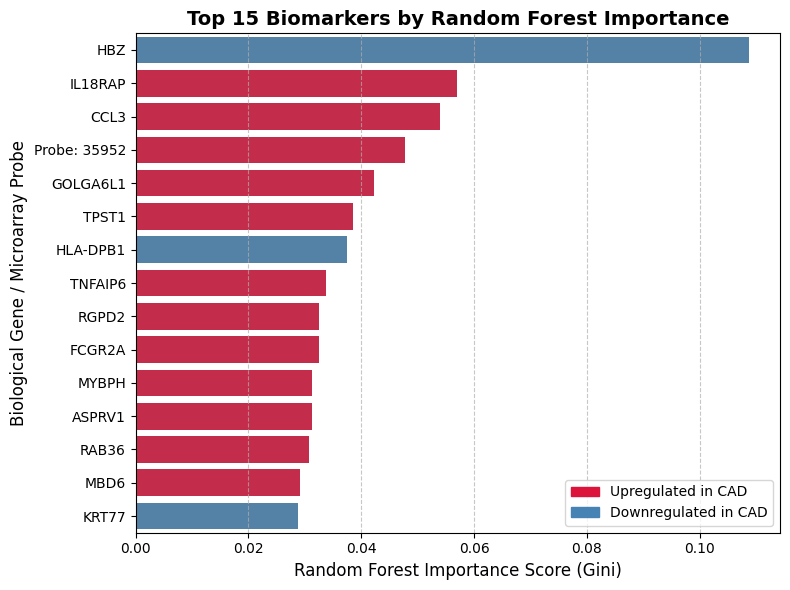

In [223]:
plt.figure(figsize=(8, 6))
colors = ['crimson' if fc > 0 else 'steelblue' for fc in df_final_map_copy['Log2FC']]
sns.barplot(x='RF_Importance', y='Display_Name', data=df_final_map_copy, palette=colors)
plt.title('Top 15 Biomarkers by Random Forest Importance', fontsize=14, fontweight='bold')
plt.xlabel('Random Forest Importance Score (Gini)', fontsize=12)
plt.ylabel('Biological Gene / Microarray Probe', fontsize=12)

red_patch = mpatches.Patch(color='crimson', label='Upregulated in CAD')
blue_patch = mpatches.Patch(color='steelblue', label='Downregulated in CAD')
plt.legend(handles=[red_patch, blue_patch], loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



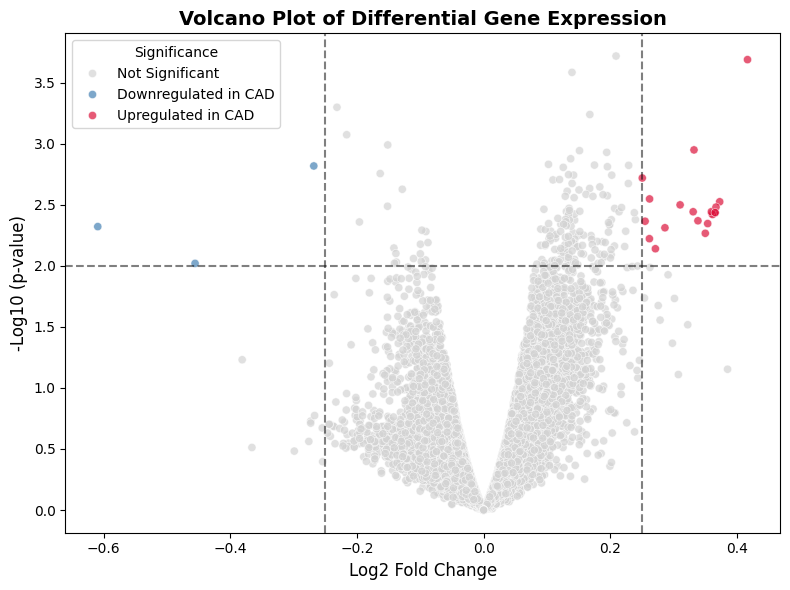

In [224]:
dge_copy['neg_log10_pval'] = -np.log10(dge_copy['p_value'])

plt.figure(figsize=(8, 6))
p_threshold, fc_threshold = -np.log10(0.01), 0.25

conditions = [
    (dge_copy['neg_log10_pval'] >= p_threshold) & (dge_copy['Log2FC'] >= fc_threshold),
    (dge_copy['neg_log10_pval'] >= p_threshold) & (dge_copy['Log2FC'] <= -fc_threshold)
]
dge_copy['Significance'] = np.select(conditions, ['Upregulated in CAD', 'Downregulated in CAD'], default='Not Significant')

palette = {'Upregulated in CAD': 'crimson', 'Downregulated in CAD': 'steelblue', 'Not Significant': 'lightgrey'}
sns.scatterplot(x='Log2FC', y='neg_log10_pval', hue='Significance', data=dge_copy, palette=palette, alpha=0.7, s=35)
plt.axhline(p_threshold, color='black', linestyle='--', alpha=0.5)
plt.axvline(fc_threshold, color='black', linestyle='--', alpha=0.5)
plt.axvline(-fc_threshold, color='black', linestyle='--', alpha=0.5)
plt.title('Volcano Plot of Differential Gene Expression', fontsize=14, fontweight='bold')
plt.xlabel('Log2 Fold Change', fontsize=12)
plt.ylabel('-Log10 (p-value)', fontsize=12)
plt.tight_layout()
plt.savefig('DGE_Volcano_Plot.png', dpi=300)
plt.show()


## Pathway Enrichment Analysis

In [225]:
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt

sig_dge = dge_df[(dge_df['p_value'] < 0.05) & (dge_df['Abs_Log2FC'] >= 0.25)].copy()
sig_dge['Gene_Probe'] = sig_dge['Gene_Probe'].astype(str)

# Merge with the annotation file (annot_subset) from Phase 5 to get Gene Symbols
sig_mapped = pd.merge(sig_dge, annot_df, left_on='Gene_Probe', right_on='ID', how='inner')

# Clean up the gene list (Drop missing values, get unique symbols)
gene_list = sig_mapped['Gene symbol'].dropna().unique().tolist()
# Microarrays sometimes list multiple genes per probe like "GENEA///GENEB". We'll just take the first one.
clean_gene_list = [str(g).split('///')[0].strip() for g in gene_list if str(g) != 'nan']

print(f"Found {len(clean_gene_list)} significant genes. Sending to KEGG database...")



Found 22 significant genes. Sending to KEGG database...


In [226]:
clean_gene_list

['KRT77',
 'MMP9',
 'ASPRV1',
 'CLEC4D',
 'CCL3',
 'SEC14L1',
 'IL18RAP',
 'TPST1',
 'ECHDC3',
 'HBZ',
 'MBD6',
 'GOLGA6L1',
 'RAB36',
 'CBS',
 'CLEC4E',
 'FCGR2A',
 'RGPD2',
 'TNFAIP6',
 'LINC00937',
 'MYBPH',
 'HSPC102',
 'HLA-DPB1']


 Found 7 significant KEGG pathways linked to CAD.


<Figure size 1000x600 with 0 Axes>

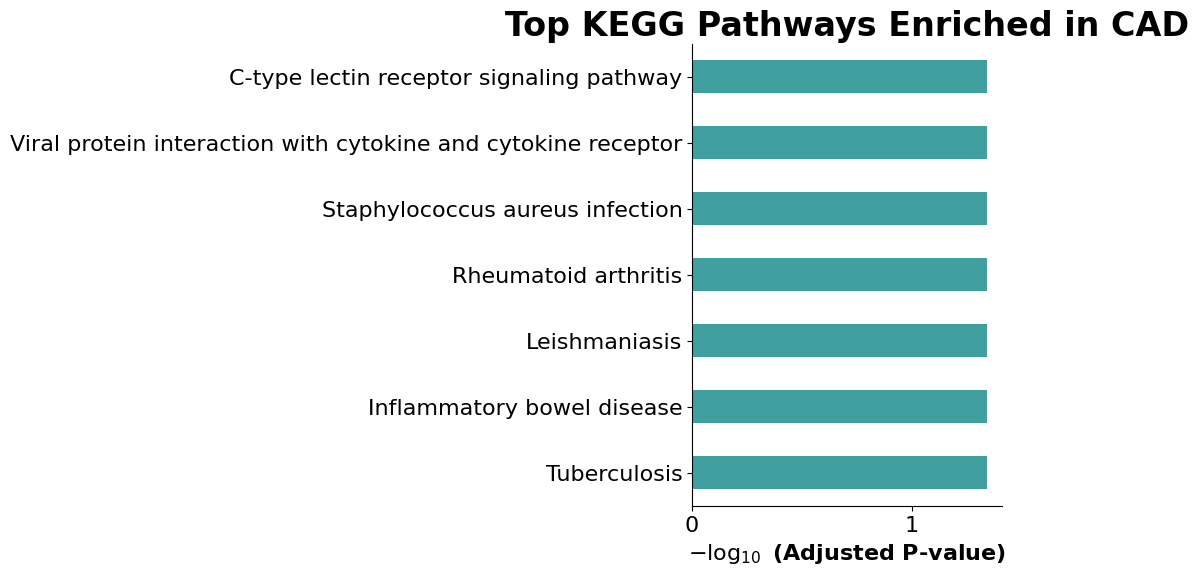

In [227]:
# Run Pathway Enrichment against the KEGG database
enr_results = gp.enrichr(gene_list=clean_gene_list,
                         gene_sets='KEGG_2021_Human',
                         organism='human',
                         outdir=None) # Keep results in memory

kegg_df = enr_results.res2d

# Visualize the Results
if kegg_df.empty:
    print("No significant pathways found. You may need to relax your p-value/Log2FC thresholds in Phase 3.")
else:
    # Filter for pathways that are actually statistically significant
    sig_pathways = kegg_df[kegg_df['Adjusted P-value'] < 0.05]
    print(f"\n Found {len(sig_pathways)} significant KEGG pathways linked to CAD.")
    
    # Bar chart 
    plt.figure(figsize=(10, 6))
    gp.barplot(enr_results.res2d, title='Top KEGG Pathways Enriched in CAD', top_term=10, color='teal')
    plt.tight_layout()
    plt.savefig('KEGG_Pathways_Barplot.png', dpi=300)
    plt.show()

In [228]:
sig_pathways

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Tuberculosis,3/180,0.000973,0.045418,0,0,17.663693,122.493414,FCGR2A;HLA-DPB1;CLEC4E
1,KEGG_2021_Human,Inflammatory bowel disease,2/65,0.002304,0.045418,0,0,31.611111,191.981016,IL18RAP;HLA-DPB1
2,KEGG_2021_Human,Leishmaniasis,2/77,0.003215,0.045418,0,0,26.537333,152.322192,FCGR2A;HLA-DPB1
3,KEGG_2021_Human,Rheumatoid arthritis,2/93,0.004651,0.045418,0,0,21.853846,117.370444,CCL3;HLA-DPB1
4,KEGG_2021_Human,Staphylococcus aureus infection,2/95,0.004848,0.045418,0,0,21.381720,113.948406,FCGR2A;HLA-DPB1
5,KEGG_2021_Human,Viral protein interaction with cytokine and cy...,2/100,0.005356,0.045418,0,0,20.285714,106.083029,IL18RAP;CCL3
6,KEGG_2021_Human,C-type lectin receptor signaling pathway,2/104,0.005780,0.045418,0,0,19.486275,100.418038,CLEC4D;CLEC4E


Prepared a ranked list of 11682 unique genes. Running GSEA...

Found 42 significant KEGG pathways.
- 36 pathways are UPREGULATED (Turned ON) in CAD.
- 6 pathways are DOWNREGULATED (Turned OFF) in CAD.


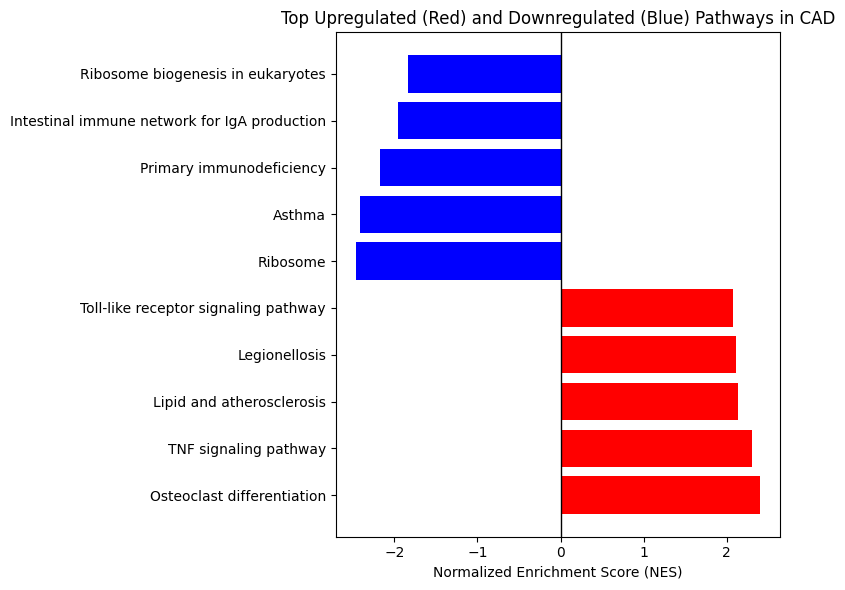

In [229]:
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt


# Force both joining columns to be strings so Pandas can match them perfectly
dge_df['Gene_Probe'] = dge_df['Gene_Probe'].astype(str)
annot_df['ID'] = annot_df['ID'].astype(str)

# Merge all genes with their annotations to get the gene symbols
full_mapped = pd.merge(dge_df, annot_df, left_on='Gene_Probe', right_on='ID', how='inner')

# Clean the Gene Symbols (handling the '///' microarray issue)
full_mapped['Clean_Symbol'] = full_mapped['Gene symbol'].astype(str).apply(lambda x: x.split('///')[0].strip())

# Drop rows where the gene symbol is missing ('nan' or empty)
full_mapped = full_mapped[(full_mapped['Clean_Symbol'] != 'nan') & (full_mapped['Clean_Symbol'] != '')]

# Handle duplicate probes for the same gene
# If multiple probes map to the same gene, we keep the one with the strongest signal (Highest Absolute Log2FC)
full_mapped['Abs_Log2FC'] = full_mapped['Log2FC'].abs()
full_mapped = full_mapped.sort_values('Abs_Log2FC', ascending=False).drop_duplicates('Clean_Symbol')

# Create the Ranked List for GSEA
# Sort strictly by the actual Log2FC (from most positive to most negative)
full_mapped = full_mapped.sort_values('Log2FC', ascending=False)

# GSEA requires a Pandas Series where the Index is the Gene Symbol, and the Value is the ranking metric (Log2FC)
ranked_list = full_mapped[['Clean_Symbol', 'Log2FC']].set_index('Clean_Symbol').squeeze()

print(f"Prepared a ranked list of {len(ranked_list)} unique genes. Running GSEA...")

# Run the Pre-ranked GSEA Algorithm against KEGG
gsea_results = gp.prerank(rnk=ranked_list,
                          gene_sets='KEGG_2021_Human',
                          permutation_num=1000, # Runs 1000 random simulations for statistical rigor
                          outdir=None,          # Keep results in memory
                          seed=42)              # Ensures reproducibility

gsea_df = gsea_results.res2d

# Filter and Interpret Results
if gsea_df.empty:
    print("No significant pathways found.")
else:
    # Filter by FDR q-val (The GSEA equivalent of Adjusted P-value)
    sig_gsea = gsea_df[gsea_df['FDR q-val'] < 0.05].copy()
    
    print(f"\nFound {len(sig_gsea)} significant KEGG pathways.")
    
    # Separate into Upregulated (NES > 0) and Downregulated (NES < 0)
    upregulated = sig_gsea[sig_gsea['NES'] > 0]
    downregulated = sig_gsea[sig_gsea['NES'] < 0]
    
    print(f"- {len(upregulated)} pathways are UPREGULATED (Turned ON) in CAD.")
    print(f"- {len(downregulated)} pathways are DOWNREGULATED (Turned OFF) in CAD.")
    
    upregulated = upregulated.sort_values(by='NES', ascending=False)
    downregulated = downregulated.sort_values(by='NES')

    top_terms = pd.concat([upregulated.head(5), downregulated.head(5)])
    
    if not top_terms.empty:
        plt.figure(figsize=(8, 6))
        # Plotting Normalized Enrichment Score (NES)
        plt.barh(top_terms['Term'], top_terms['NES'], color=['red' if x > 0 else 'blue' for x in top_terms['NES']])
        plt.xlabel('Normalized Enrichment Score (NES)')
        plt.title('Top Upregulated (Red) and Downregulated (Blue) Pathways in CAD')
        plt.axvline(0, color='black', linewidth=1)
        plt.tight_layout()
        plt.savefig('GSEA_Pathways.png', dpi=300)
        plt.show()